In [1]:
import sys
sys.path.insert(0, "../../build/python")


import gdcm_connector
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
sample_file_path = "../../dicom_samples/1-02.dcm"

In [3]:
metadata = gdcm_connector.read_basic_metadata(sample_file_path)

metadata

{'patient_name': 'HANCOCK^KRISTI',
 'patient_id': '8203339059',
 'study_instance_uid': '3.2.122.1.2.8066147.5.661.1012732735847470399',
 'series_instance_uid': '3.2.122.1.2.8066147.5.661.3076430383400550560',
 'sop_instance_uid': '3.2.122.1.2.8066147.5.661.3773330481979389314',
 'modality': 'CR',
 'transfer_syntax': '1.2.840.10008.1.2.1'}

In [4]:
modality = gdcm_connector.read_tag(sample_file_path, 0x0008, 0x0060)

modality

'CR'

In [5]:
pixels = gdcm_connector.read_pixels(sample_file_path)

pixels.keys()

dict_keys(['data', 'dimensions', 'samples_per_pixel', 'bits_allocated', 'bits_stored', 'high_bit', 'pixel_representation', 'scalar_type', 'photometric_interpretation', 'transfer_syntax'])

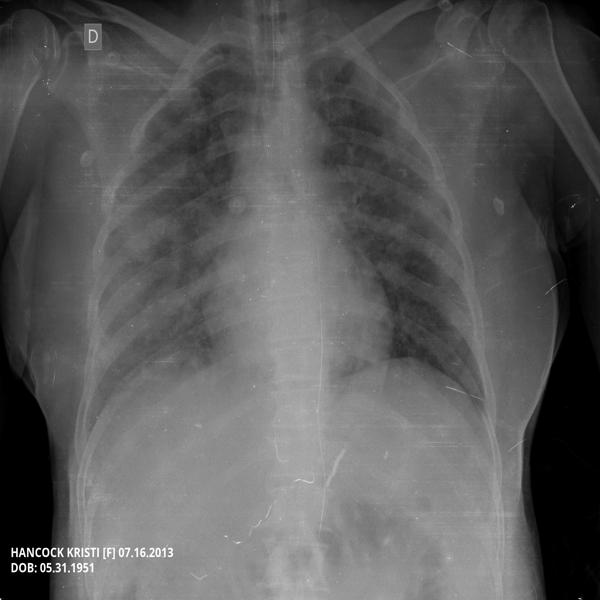

In [6]:
dtype_map = {
    "UINT8": np.uint8,
    "INT8": np.int8,
    "UINT16": np.uint16,
    "INT16": np.int16,
    "UINT32": np.uint32,
    "INT32": np.int32,
    "FLOAT32": np.float32,
    "FLOAT64": np.float64,
}

dtype = dtype_map[pixels["scalar_type"]]
arr = np.frombuffer(pixels["data"], dtype=dtype)

width, height = pixels["dimensions"][:2]
samples = pixels["samples_per_pixel"]

if samples == 1:
    image = arr.reshape(height, width)
else:
    image = arr.reshape(height, width, samples)

display(Image.fromarray(image).resize((600,600)))